In [1]:
#Business Understanding

#######################################################################
#Projekt: Hotel Bookings: Przewidywanie Anulacji Rezerwacji Hotelowych
#######################################################################

##PROBLEM BIZNESOWY:
#Anulacje rezerwacji hotelowych generują straty finansowe oraz utrudniają zarządzanie zasobami hotelu.

##CEL BIZNESOWY:
#Ograniczenie strat wynikających z niespodziewanych anulowań rezerwacji poprzez wdrożenie systemu wczesnego ostrzegania.

##CEL ANALITYCZNY:
#Zbudowanie modelu klasyfikacji binarnej przewidującego, czy dana rezerwacja zostanie anulowana (is_canceled = 1), czy zrealizowana (is_canceled = 0).

##MIARA SUKCESU:
# Biznesowa: Stabilniejsza alokacja zasobów hotelowych.
# Analityczna: F1-Score minimum 75% dla klasy 1 (anulowania).

In [2]:
#Data Understanding

#Import Bibliotek i Przygotowanie Środowiska

#Import bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#Biblioteki do uczenia maszynowego
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#Ustawienia środowiska
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

print("Biblioteki zaimportowane poprawnie.")

Biblioteki zaimportowane poprawnie.


In [3]:
#Wczytanie zbioru danych
df = pd.read_csv('hotel_bookings.csv', na_values=['NULL', 'NaN'])
print("Wczytano zbiór danych.")

Wczytano zbiór danych.


Wstępna weryfikacja zbioru danych
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-n

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Liczba wierszy będących całkowitymi duplikatami: 31994
Liczba brakujących wartości (NaN)
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_t

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


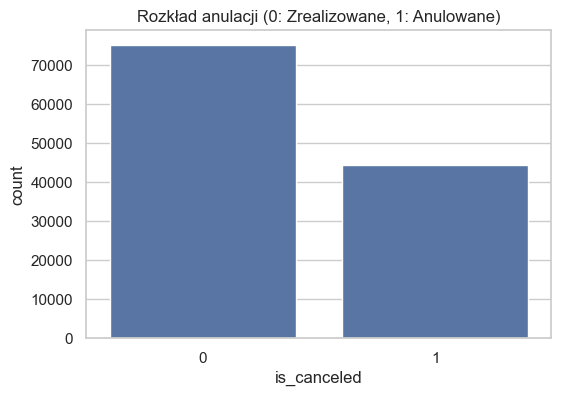

In [4]:
#Wstępna weryfikacja zbioru danych
print("Wstępna weryfikacja zbioru danych")
df.info()

#Sprawdzenie 5 pierwszych wierszy
print("Pierwsze 5 wierszy")
display(df.head())

#Sprawdzenie duplikatów
num_duplicates = df.duplicated().sum()
print(f"Liczba wierszy będących całkowitymi duplikatami: {num_duplicates}")

#Sprawdzenie brakujących danych
print("Liczba brakujących wartości (NaN)")
print(df.isnull().sum())

#Sprawdzenie unikalnych wartości
print("Liczba unikalnych wartości w każdej kolumnie")
print(df.nunique())

#Podstawowe statystyki opisowe
print("Statystyki opisowe dla liczb")
display(df.describe().T)

#Sprawdzenie rozkładu zmiennej celu
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df)
plt.title("Rozkład anulacji (0: Zrealizowane, 1: Anulowane)")
plt.show()

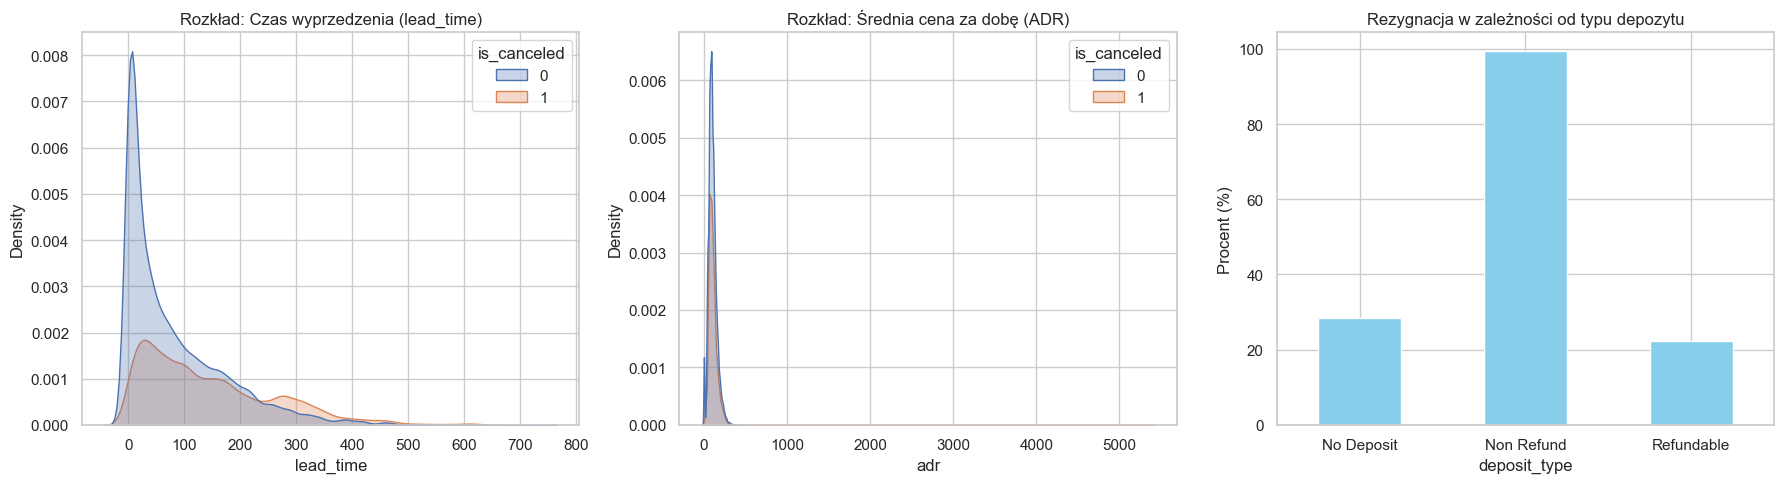

In [5]:
#Analiza Eksploracyjna (EDA)

#Tworzenie siatki wykresów
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Wykres dla zmiennej lead_time (Czas wyprzedzenia (dni))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, ax=axes[0], alpha=0.3)
axes[0].set_title('Rozkład: Czas wyprzedzenia (lead_time)')

#Wykres dla zmiennej adr (Średnia cena za dobę (ADR))
sns.kdeplot(data=df, x='adr', hue='is_canceled', fill=True, ax=axes[1], alpha=0.3)
axes[1].set_title('Rozkład: Średnia cena za dobę (ADR)')

#Wykres dla zmiennej deposit_type (Typ depozytu) + grupowanie
deposit_data = df.groupby('deposit_type')['is_canceled'].mean() * 100
deposit_data.plot(kind='bar', ax=axes[2], color='skyblue')
axes[2].set_title('Rezygnacja w zależności od typu depozytu')
axes[2].set_ylabel('Procent (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.show()

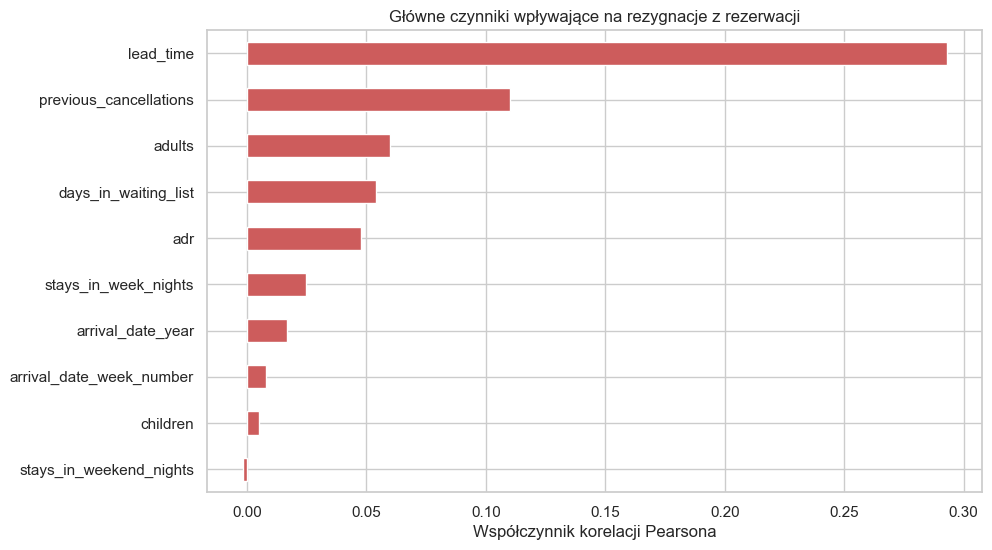

In [6]:
#Analiza Korelacji

#Współczynnik korelacji ze zmienną celu (is_canceled)
plt.figure(figsize=(10, 6))

corr_series = df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)

#Usunięcie autokorelacji zmiennej celu
corr_series = corr_series.drop('is_canceled')

#Wykres 10 cech najbardziej skorelowanych ze zmienną celu
corr_series.head(10).plot(kind='barh', color='indianred')
plt.title("Główne czynniki wpływające na rezygnacje z rezerwacji")
plt.xlabel("Współczynnik korelacji Pearsona")
plt.gca().invert_yaxis()
plt.show()

In [7]:
#Data Preparation

#Usunięcie duplikatów 
initial_len = len(df)
df_clean = df.drop_duplicates().copy()
print(f"Usunięto {initial_len - len(df_clean)} duplikatów.")

#Uzupełnienie brakujących danych
df_clean['children'] = df_clean['children'].fillna(0)
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['country'] = df_clean['country'].fillna('Unknown') # Zatrzymujemy kolumnę!

#Usunięcie kolumny company
df_clean.drop(columns=['company'], inplace=True, errors='ignore')

#Usunięcie rekordów z błędnym ADR i rezerwacji z brakiem gości
df_clean = df_clean[(df_clean['adr'] >= 0) & (df_clean['adr'] < 1000)]
df_clean = df_clean[(df_clean['adults'] + df_clean['children'] + df_clean['babies']) > 0]

#Usunięcie wycieków danych
leaked_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type']
df_clean.drop(columns=leaked_cols, inplace=True, errors='ignore')

#Weryfikacja końcowa
print(f"Podsumowanie czyszczenia")
print(f"Pozostało wierszy: {len(df_clean)}")
print(f"Brakujące wartości po czyszczeniu: {df_clean.isnull().sum().sum()}")

Usunięto 31994 duplikatów.
Podsumowanie czyszczenia
Pozostało wierszy: 87228
Brakujące wartości po czyszczeniu: 0


In [8]:
#Inżynieria Cech

#Zmiana tekstu na liczby + chronologia
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_clean['arrival_date_month'] = df_clean['arrival_date_month'].map(month_map)

#Inżynieria nowych cech
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']

#Usunięcie zmiennej country
if 'country' in df_clean.columns:
    df_clean = df_clean.drop(columns=['country'])

#One-Hot Encoding dla wybranych zmiennych
cols_to_encode = ['hotel', 'meal', 'market_segment', 
                  'distribution_channel', 'reserved_room_type', 
                  'deposit_type', 'customer_type']

df_final = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True, dtype=int)

#Weryfikacja końcowa
print(f"Zakończono! Liczba wierszy: {df_final.shape[0]}, Liczba kolumn: {df_final.shape[1]}")

Zakończono! Liczba wierszy: 87228, Liczba kolumn: 51


In [9]:
print(df['hotel'].unique())

['Resort Hotel' 'City Hotel']


In [10]:
#Przygotowanie zbioru danych do dalszej pracy

#Wyodrębnienie X oraz y
X = df_final.drop(columns=['is_canceled', 'country'], errors='ignore')
y = df_final['is_canceled']

#Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Zapisanie gotowych zbiorów do plików CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("\nDane zostały podzielone (80% trening, 20% test) i zapisane do 4 plików CSV.")
print("Gotowe!")


Dane zostały podzielone (80% trening, 20% test) i zapisane do 4 plików CSV.
Gotowe!


In [11]:
#Generowanie Słownika Danych i Statystyk Opisowych


import pandas as pd

# Zmienne oryginalne przed encodingiem
original_vars = [
    'hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month',
    'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
    'children', 'babies', 'meal', 'market_segment', 'distribution_channel',
    'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'reserved_room_type',
    'booking_changes', 'deposit_type', 'agent', 'days_in_waiting_list',
    'customer_type', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'total_nights', 'total_guests'
]

polish_names = {
    'hotel': 'Typ hotelu',
    'lead_time': 'Czas wyprzedzenia (dni)',
    'arrival_date_year': 'Rok przyjazdu',
    'arrival_date_month': 'Miesiąc przyjazdu',
    'arrival_date_week_number': 'Numer tygodnia przyjazdu',
    'arrival_date_day_of_month': 'Dzień miesiąca przyjazdu',
    'stays_in_weekend_nights': 'Liczba nocy w weekend',
    'stays_in_week_nights': 'Liczba nocy w tygodniu',
    'adults': 'Liczba dorosłych',
    'children': 'Liczba dzieci',
    'babies': 'Liczba niemowląt',
    'meal': 'Typ posiłku',
    'market_segment': 'Segment rynku',
    'distribution_channel': 'Kanał dystrybucji',
    'is_repeated_guest': 'Stały gość',
    'previous_cancellations': 'Poprzednie anulacje',
    'previous_bookings_not_canceled': 'Poprzednie rezerwacje bez anulacji',
    'reserved_room_type': 'Typ zarezerwowanego pokoju',
    'booking_changes': 'Liczba zmian w rezerwacji',
    'deposit_type': 'Typ depozytu',
    'agent': 'Identyfikator agenta',
    'days_in_waiting_list': 'Dni na liście oczekujących',
    'customer_type': 'Typ klienta',
    'adr': 'Średnia cena za dobę (ADR)',
    'required_car_parking_spaces': 'Wymagane miejsca parkingowe',
    'total_of_special_requests': 'Liczba specjalnych życzeń',
    'total_nights': 'Łączna liczba nocy (nowa)',
    'total_guests': 'Łączna liczba gości (nowa)'
}

# Budujemy słownik na df_clean (przed get_dummies)
data_dict = []
for col in original_vars:
    if col not in df_clean.columns:
        continue
    pol_name = polish_names.get(col, col)
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        var_type = 'Binarna' if df_clean[col].nunique() == 2 else 'Ilościowa'
        stats = df_clean[col].describe()
        row = {
            'Nazwa zmiennej': col,
            'Opis': pol_name,
            'Typ': var_type,
            'Min': round(stats['min'], 2),
            'Max': round(stats['max'], 2),
            'Średnia': round(stats['mean'], 2),
            'Odch. std.': round(stats['std'], 2)
        }
    else:
        var_type = 'Kategorialna'
        row = {
            'Nazwa zmiennej': col,
            'Opis': pol_name,
            'Typ': var_type,
            'Min': '-', 'Max': '-', 'Średnia': '-', 'Odch. std.': '-'
        }
    data_dict.append(row)

df_dict = pd.DataFrame(data_dict)
df_dict.to_csv('slownik_danych.csv', index=False)
print(df_dict.to_string(index=False))

                Nazwa zmiennej                               Opis          Typ     Min     Max  Średnia Odch. std.
                         hotel                         Typ hotelu Kategorialna       -       -        -          -
                     lead_time            Czas wyprzedzenia (dni)    Ilościowa     0.0   737.0    79.97      86.06
             arrival_date_year                      Rok przyjazdu    Ilościowa  2015.0  2017.0  2016.21       0.69
            arrival_date_month                  Miesiąc przyjazdu    Ilościowa     1.0    12.0     6.47        3.1
      arrival_date_week_number           Numer tygodnia przyjazdu    Ilościowa     1.0    53.0    26.84      13.67
     arrival_date_day_of_month           Dzień miesiąca przyjazdu    Ilościowa     1.0    31.0    15.82       8.84
       stays_in_weekend_nights              Liczba nocy w weekend    Ilościowa     0.0    19.0      1.0       1.03
          stays_in_week_nights             Liczba nocy w tygodniu    Ilościowa  

In [12]:
# Szybkie podsumowanie podziału
print(f"Zbiór treningowy: {X_train.shape[0]} wierszy")
print(f"Zbiór testowy: {X_test.shape[0]} wierszy")
print(f"Proporcja anulacji w train: {y_train.mean():.2%}")
print(f"Proporcja anulacji w test: {y_test.mean():.2%}")

Zbiór treningowy: 69782 wierszy
Zbiór testowy: 17446 wierszy
Proporcja anulacji w train: 27.60%
Proporcja anulacji w test: 27.21%
